In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.monte_carlo import (
    simulate_portfolio_returns,
    calculate_var,
    calculate_expected_shortfall,
    simulation_summary
)

In [3]:
mean_return = 0.08
volatility = 0.15

portfolio_paths = simulate_portfolio_returns(
    mean_return=mean_return,
    volatility=volatility,
    num_simulations=10000,
    time_horizon=252
)

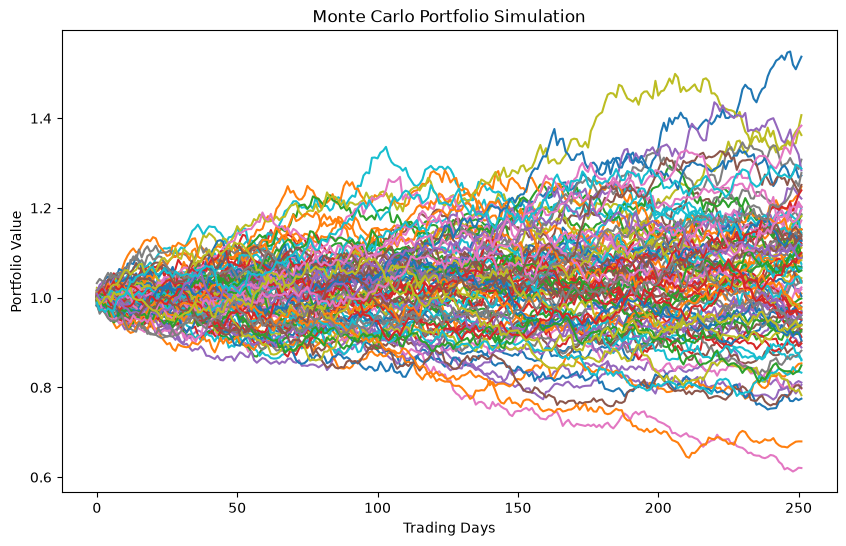

In [4]:
plt.figure(figsize=(10,6))

plt.plot(portfolio_paths[:, :100])

plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")

plt.show()

In [5]:
var = calculate_var(
    portfolio_paths,
    confidence_level=0.95
)

es = calculate_expected_shortfall(
    portfolio_paths,
    confidence_level=0.95
)

print(f"Value at Risk (95%): {var:.4f}")
print(f"Expected Shortfall (95%): {es:.4f}")

Value at Risk (95%): 0.8373
Expected Shortfall (95%): 0.7845


In [6]:
summary = simulation_summary(
    portfolio_paths,
    confidence_level=0.95
)

summary

,Metric,Value
0,Mean Final Value,1.082819
1,Median Final Value,1.071919
2,Minimum Value,0.526973
3,Maximum Value,2.019962
4,VaR,0.837277
5,Expected Shortfall,0.784509


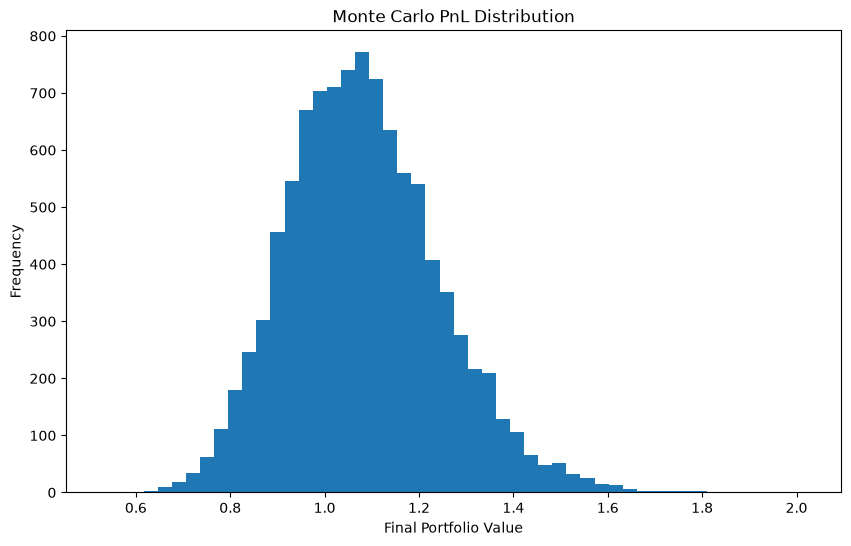

In [7]:
plt.figure(figsize=(10,6))

plt.hist(
    portfolio_paths[-1],
    bins=50
)

plt.title("Monte Carlo PnL Distribution")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")

plt.show()